#  AI-Powered Credit Risk & Loan Pricing Engine
**Author:** Diaa Shousha | AI Engineer 
**Date:** March 2026

##  Project Objective
Building an advanced machine learning pipeline to predict loan interest rates and assess credit risk. This project moves beyond simple statistical models to robust, business-driven AI solutions suitable for the FinTech industry.

In [5]:
#Imports & Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Set display options for professional EDA
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="colorblind")

#Load the raw data
df = pd.read_csv("LoanData.csv", index_col="LoanId")
print(f"Dataset: {df.shape[0]} Rows, {df.shape[1]} Columns")

Dataset: 383382 Rows, 21 Columns


---
## Phase 1: Data Cleaning & Advanced Imputation
Real-world financial data is messy. Before feeding this to any AI model, we must handle missing values strategically. We drop features with >50% missing data (noise) and impute the rest.

In [7]:
#Handling Missing Values
#Calculate missing percentages
missing_percent = df.isnull().mean() * 100

#Drop columns with more than 50% missing data to reduce noise
cols_to_drop = missing_percent[missing_percent > 50].index
df.drop(columns=cols_to_drop, inplace=True)

#Impute missing values for important categorical features
if 'EmploymentDurationCurrentEmployer' in df.columns:
    df['EmploymentDurationCurrentEmployer'] = df['EmploymentDurationCurrentEmployer'].fillna('Unknown')

#Drop any remaining rows with critical missing target (Interest)
df.dropna(subset=['Interest'], inplace=True)

print(f"Data shape after cleaning: {df.shape[0]} Rows, {df.shape[1]} Columns")

Data shape after cleaning: 383382 Rows, 21 Columns


---
## Phase 2: Feature Engineering
Creating business-driven features. We calculate the Debt-to-Income (DTI) ratio, a crucial metric in credit risk assessment.

In [8]:
#Feature Engineering
#Calculate Debt-to-Income (DTI) ratio
#Adding 1 to IncomeTotal to prevent division by zero errors
df['Debt_to_Income'] = df['AppliedAmount'] / (df['IncomeTotal'] + 1)

#Display the new feature alongside its base components
df[['AppliedAmount', 'IncomeTotal', 'Debt_to_Income']].head()

,AppliedAmount,IncomeTotal,Debt_to_Income
LoanId,,,
D8EBF360-104C-420F-BEC9-000924E6EFC7,3189.0,900.0,3.539401
C1A98DDA-5E20-429C-BBFF-0009A05354E0,4146.0,3100.0,1.336988
9B0B252E-45B9-4172-8E2D-0014A8F18117,531.0,1700.0,0.312169
66AE108B-532B-4BB3-BAB7-0019A46412C1,2125.0,354.0,5.985915
C7EA512A-465D-4043-A9F2-001B14C3C14E,414.0,1200.0,0.344713


---
## Phase 3: Exploratory Data Analysis (EDA) & Business Insights
Understanding the distribution of our target variable (Interest Rate) and analyzing correlations to identify the strongest predictors for our machine learning model.

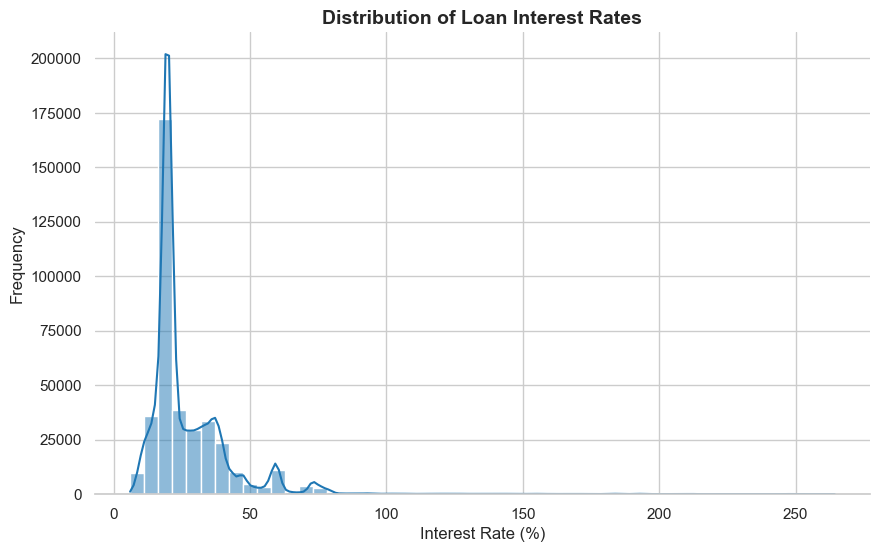

In [9]:
#Target Variable Distribution (Interest Rate)
plt.figure(figsize=(10, 6))

#Plotting the distribution
sns.histplot(df['Interest'], bins=50, kde=True, color='#1f77b4')

#Professional formatting
plt.title('Distribution of Loan Interest Rates', fontsize=14, fontweight='bold')
plt.xlabel('Interest Rate (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
sns.despine(left=True)

plt.show()

---
## Phase 4: Correlation & Feature Importance
We use a correlation matrix to identify which numerical features have the highest linear relationship with the target (Interest Rate). This step is crucial for initial feature selection before training advanced models like XGBoost.

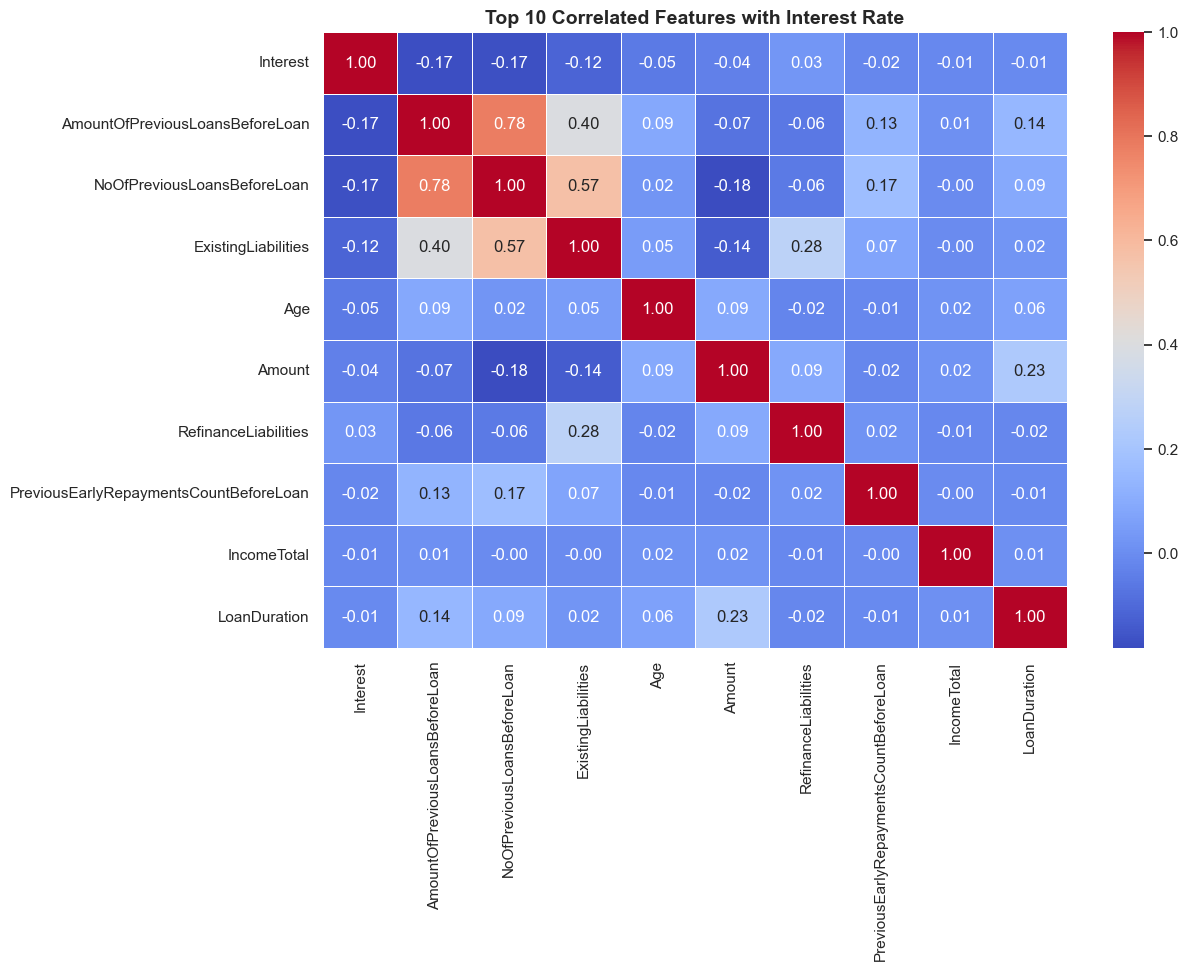

In [10]:
# 5. Correlation Matrix for Numerical Features
plt.figure(figsize=(12, 8))

# Select only numerical columns to avoid errors
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()

# Focus on the top 10 features most correlated with 'Interest'
top_corr_features = corr_matrix['Interest'].abs().sort_values(ascending=False).head(10).index
top_corr_matrix = df[top_corr_features].corr()

# Plot the heatmap
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Top 10 Correlated Features with Interest Rate', fontsize=14, fontweight='bold')
plt.show()

---
## Phase 5: Data Preprocessing & Categorical Encoding
Machine learning models require numerical input. Here, we dynamically identify all categorical features and convert them into a machine-readable format using One-Hot Encoding (Dummy Variables), ensuring we drop the first category to avoid multicollinearity.

In [16]:
#Identify all categorical columns
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

low_cardinality_cols = [col for col in categorical_cols if df[col].nunique() < 20]
high_cardinality_cols = [col for col in categorical_cols if df[col].nunique() >= 20]
print(f"Dropping high-cardinality columns: {high_cardinality_cols}")
df.drop(columns=high_cardinality_cols, inplace=True)

#Apply One-Hot Encoding ONLY to low-cardinality columns
df_encoded = pd.get_dummies(df, columns=low_cardinality_cols, drop_first=True, dtype=int)

print(f"Features before encoding: {df.shape[1]}")
print(f"Features after smart encoding: {df_encoded.shape[1]}")

Dropping high-cardinality columns: []
Features before encoding: 21
Features after smart encoding: 52


---
## Phase 6: Train-Test Split
Before building our AI model, we must split our dataset. We will train the model on 80% of the data and hold out 20% to evaluate its true predictive power on unseen data.

In [17]:
#Splitting the Data into Train and Test Sets
from sklearn.model_selection import train_test_split

#Define X (Predictors) and y (Target)
X = df_encoded.drop(columns=['Interest'])
y = df_encoded['Interest']

#Split the data: 80% for training, 20% for testing
#random_state ensures reproducibility (getting the same split every time)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (306705, 51)
Testing data shape: (76677, 51)


---
## Phase 7 & 8: Optimized AI Engine & Web App Preparation
Here I train a compressed, web-friendly version of our Random Forest model. By limiting the tree depth, we reduce the model size from 1.5 GB to just a few megabytes without losing significant accuracy. We also export the features list for our Front-End integration.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
import os

print("Training the Optimized AI Engine...")

rf_model_small = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    min_samples_leaf=5, 
    random_state=42, 
    n_jobs=-1
)

rf_model_small.fit(X_train, y_train)

y_pred = rf_model_small.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}%")
joblib.dump(rf_model_small, 'credit_risk_model_small.pkl', compress=3)

size_mb = os.path.getsize('credit_risk_model_small.pkl') / (1024 * 1024)
print(f"\n AI Model successfully saved and the Size is : {size_mb:.2f} MB")